# E2 — Robust real-vs-synthetic distribution audit

This notebook quantifies how different the **real** Jamming anomaly windows are from the
**synthetic** anomaly windows in the TelecomTS 5G dataset, using only numeric KPI signals
(no text fields, no anomaly-type names as features).

The analysis is layered:

* Per-KPI distribution tests (KS, Cohen's d, Wasserstein, bootstrap CI on mean diff).
* Classifier two-sample tests (C2ST) with three model families and five feature subsets.
* RBF-kernel MMD test with a permutation null.
* Context-matched robustness analysis (exact match on `(zone, application, mobility,
  congestion)` with a propensity-score fallback) so we can disentangle the gap from the
  deployment context.
* Three-way centroid distances (`normal` vs `real` vs `synthetic`).

We rely on the shared infrastructure in `_shared/data_utils.py` and `_shared/notebook_helpers.py`
(corpus loader, engineered KPI summary features, statistics helpers). The notebook is
self-contained beyond `_shared.*` and standard scientific libraries.


In [1]:
# Section 0.1 — bootstrap: paths, plotting, imports.
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))

from _shared.notebook_helpers import setup_paths, configure_matplotlib
EXPERIMENTS_ROOT = setup_paths()
configure_matplotlib()

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp, wasserstein_distance

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, balanced_accuracy_score
from sklearn.neighbors import NearestNeighbors

from _shared.data_utils import (
    load_corpus,
    extract_kpi_summary_features,
    get_or_build_corpus_features,
    feature_names,
    kpi_for_feature,
    feature_indices_for_kpis,
    KPI_NAMES,
    KPI_GROUPS,
    ANOMALY_TYPES,
    REAL_ANOMALY_TYPES,
    SYNTHETIC_ANOMALY_TYPES,
    CONTEXT_FIELDS,
    cohens_d,
    bootstrap_mean_diff_ci,
    benjamini_hochberg,
    per_kpi_stat_means,
)

HERE = Path('.').resolve()
RESULTS = HERE / 'results'
FIGURES = HERE / 'figures'
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
print('Working dir   :', HERE)
print('Results dir   :', RESULTS)
print('Figures dir   :', FIGURES)


Working dir   : experiments/E2_distribution_gap_robustness
Results dir   : experiments/E2_distribution_gap_robustness/results
Figures dir   : experiments/E2_distribution_gap_robustness/figures


In [2]:
# Section 0.2 — load corpus and engineered features (cached).
corpus = load_corpus(verbose=True)
F_full, feat_names = get_or_build_corpus_features(verbose=True)

print('corpus.n        =', corpus.n)
print('F_full.shape    =', F_full.shape)
print('len(feat_names) =', len(feat_names))
assert F_full.shape == (corpus.n, 240), 'expected 240 engineered features'
assert len(feat_names) == 240


[data_utils] Loading cached corpus from experiments/_shared/cache/telecomts_corpus_v1.pkl
[data_utils] Loading cached corpus features from experiments/_shared/cache/telecomts_kpi_summary_features_v1.npz
corpus.n        = 32000
F_full.shape    = (32000, 240)
len(feat_names) = 240


In [3]:
# Section 0.3 — anomaly subset masks and quick counts.
real_mask = corpus.anomaly_origin == 'real'
synth_mask = corpus.anomaly_origin == 'synthetic'
norm_mask = corpus.anomaly_origin == 'normal'
n_real = int(real_mask.sum())
n_synth = int(synth_mask.sum())
n_norm = int(norm_mask.sum())
print(f'real (Jamming)        : {n_real}')
print(f'synthetic (other 10)  : {n_synth}')
print(f'normal                : {n_norm}')
assert set(REAL_ANOMALY_TYPES) == {'Jamming'}, 'real definition must remain Jamming-only'

# Per-window KPI mean (used by Part A and as the kpi_means feature set).
window_means = corpus.X.mean(axis=1)  # (N, 16) float32
real_means_full = window_means[real_mask].astype(np.float64)
synth_means_full = window_means[synth_mask].astype(np.float64)
print('real_means_full.shape  =', real_means_full.shape)
print('synth_means_full.shape =', synth_means_full.shape)


real (Jamming)        : 279
synthetic (other 10)  : 956
normal                : 30765
real_means_full.shape  = (279, 16)
synth_means_full.shape = (956, 16)


## Goal

Quantify the distributional gap between **real Jamming** anomalies and **synthetic**
anomalies using numeric KPI data only, and test whether the gap remains after
controlling for deployment context (`zone`, `application`, `mobility`, `congestion`).

Concretely we want to answer two questions:

1. Are the marginal and joint distributions over KPIs detectably different between real
   and synthetic anomalies, with rigorous multiple-testing control?
2. If yes, is the gap an artefact of context imbalance (e.g. real Jamming is mostly Zone
   B + YouTube while synthetic anomalies span everything), or does it persist on a
   context-matched subset?

We deliberately use only numeric KPIs and engineered features. We never feed
anomaly-type strings, descriptions, or troubleshooting tickets to any model.


## Part A — Per-KPI distribution tests

For each of the 16 KPIs we compare the distribution of per-window means between
real Jamming and synthetic anomalies using:

* Kolmogorov–Smirnov (`scipy.stats.ks_2samp`) statistic and p-value.
* Cohen's d (pooled-std effect size, from `_shared.data_utils.cohens_d`).
* Wasserstein-1 distance (`scipy.stats.wasserstein_distance`).
* 95% bootstrap CI for `mean(real) - mean(synth)` with 2000 resamples (seed 0).

We then apply both Bonferroni and Benjamini–Hochberg (BH, FDR=0.05) corrections
across the 16 KPIs, and rank KPIs by KS, |Cohen's d|, and a Wasserstein distance
standardised by the pooled standard deviation of that KPI.


In [4]:
# Helper: per-KPI distribution tests on a real/synthetic per-window-mean pair.
def per_kpi_tests(real_means: np.ndarray, synth_means: np.ndarray) -> pd.DataFrame:
    """Run KS / Cohen's d / Wasserstein / bootstrap CI for each KPI column."""
    rows = []
    for j, kpi in enumerate(KPI_NAMES):
        a = real_means[:, j].astype(float)
        b = synth_means[:, j].astype(float)
        ks_stat, ks_p = ks_2samp(a, b)
        d = cohens_d(a, b)
        wd = wasserstein_distance(a, b)
        obs, lo, hi = bootstrap_mean_diff_ci(a, b, n_boot=2000, seed=0)
        # Pooled std for Wasserstein normalisation.
        na, nb_ = a.size, b.size
        if na < 2 or nb_ < 2:
            pooled = float('nan')
        else:
            pooled = float(np.sqrt(((na - 1) * a.var(ddof=1) + (nb_ - 1) * b.var(ddof=1)) / (na + nb_ - 2)))
        wd_z = float(wd / pooled) if (pooled and pooled > 0) else float('nan')
        rows.append({
            'kpi': kpi,
            'n_real': int(na),
            'n_synth': int(nb_),
            'mean_real': float(a.mean()),
            'mean_synth': float(b.mean()),
            'mean_diff': obs,
            'ci_lo': lo,
            'ci_hi': hi,
            'ks_stat': float(ks_stat),
            'ks_p': float(ks_p),
            'cohens_d': d,
            'abs_d': float(abs(d)) if d == d else float('nan'),
            'wasserstein': float(wd),
            'pooled_std': pooled,
            'wasserstein_z': wd_z,
        })
    df = pd.DataFrame(rows)
    m = len(df)
    df['bonferroni_alpha'] = 0.05 / m
    df['bonferroni_sig'] = df['ks_p'] < df['bonferroni_alpha']
    df['bh_sig'] = benjamini_hochberg(df['ks_p'].values, alpha=0.05)
    return df


per_kpi_full = per_kpi_tests(real_means_full, synth_means_full)
per_kpi_full.to_csv(RESULTS / 'E2_per_kpi_real_synthetic_tests.csv', index=False)
print('saved', RESULTS / 'E2_per_kpi_real_synthetic_tests.csv')
per_kpi_full


saved experiments/E2_distribution_gap_robustness/results/E2_per_kpi_real_synthetic_tests.csv


,kpi,n_real,n_synth,mean_real,mean_synth,mean_diff,ci_lo,ci_hi,ks_stat,ks_p,cohens_d,abs_d,wasserstein,pooled_std,wasserstein_z,bonferroni_alpha,bonferroni_sig,bh_sig
0,RSRP,279,956,-76.013554,-108.669133,32.655579,31.860246,33.447713,1.000000,1.995634e-285,3.168762,3.168762,32.655579,10.305468,3.168762,0.003125,True,True
1,DL_BLER,279,956,0.011119,0.012558,-0.001438,-0.006902,0.003246,0.688974,1.144602e-99,-0.021276,0.021276,0.014854,0.067608,0.219704,0.003125,True,True
2,DL_MCS,279,956,6.947110,6.302970,0.644140,0.532913,0.755601,0.234786,6.069848e-11,0.449480,0.449480,0.644140,1.433078,0.449480,0.003125,True,True
3,UL_BLER,279,956,0.062720,0.099738,-0.037018,-0.046029,-0.028444,0.416194,3.716594e-34,-0.361367,0.361367,0.040532,0.102440,0.395664,0.003125,True,True
4,UL_MCS,279,956,13.405579,13.600656,-0.195076,-0.685818,0.292059,0.176085,2.490087e-06,-0.038573,0.038573,1.837894,5.057325,0.363412,0.003125,True,True
5,UL_NPRB,279,956,13.626830,14.961140,-1.334310,-2.403245,-0.275431,0.155693,4.835909e-05,-0.136199,0.136199,2.270399,9.796792,0.231749,0.003125,True,True
6,UL_SNR,279,956,20.734827,17.549176,3.185651,2.915090,3.459150,0.611925,1.156607e-76,0.885843,0.885843,3.185654,3.596181,0.885844,0.003125,True,True
7,TX_Bytes,279,956,180215.217098,121956.557041,58258.660057,34076.344169,80404.435435,0.292636,7.779577e-17,0.361188,0.361188,58281.788740,161297.270477,0.361332,0.003125,True,True
8,RX_Bytes,279,956,3391.836498,2057.062255,1334.774243,1038.647648,1623.425946,0.365426,3.121959e-26,0.664098,0.664098,1334.774243,2009.906641,0.664098,0.003125,True,True
9,Estimated_UL_Buffer,279,956,646.906582,4923.974120,-4277.067538,-5859.899257,-2746.247035,0.215429,2.845665e-09,-0.205116,0.205116,4328.690011,20851.972528,0.207591,0.003125,True,True


In [5]:
# Rankings: KS, |Cohen's d|, Wasserstein-z (per-KPI standardised).
def rank_per_kpi(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        'rank': np.arange(1, len(df) + 1, dtype=int),
        'rank_ks': df.sort_values('ks_stat', ascending=False)['kpi'].values,
        'rank_abs_d': df.sort_values('abs_d', ascending=False)['kpi'].values,
        'rank_wasserstein_z': df.sort_values('wasserstein_z', ascending=False)['kpi'].values,
    })


rankings_full = rank_per_kpi(per_kpi_full)
rankings_full.to_csv(RESULTS / 'E2_per_kpi_rankings.csv', index=False)
print('saved', RESULTS / 'E2_per_kpi_rankings.csv')
rankings_full


saved experiments/E2_distribution_gap_robustness/results/E2_per_kpi_rankings.csv


,rank,rank_ks,rank_abs_d,rank_wasserstein_z
0,1,RSRP,RSRP,RSRP
1,2,DL_BLER,UL_SNR,UL_SNR
2,3,UL_SNR,RX_Bytes,RX_Bytes
3,4,UL_BLER,DL_MCS,DL_MCS
4,5,RX_Bytes,PRBs_UL_Current,UL_BLER
5,6,PRB_Utilization_DL,UL_BLER,PRBs_UL_Current
6,7,TX_Bytes,TX_Bytes,UL_MCS
7,8,PRB_Utilization_UL,PRB_Utilization_UL,PRB_Utilization_UL
8,9,DL_MCS,Estimated_UL_Buffer,TX_Bytes
9,10,PRBs_UL_Current,DL_NumberOfPackets,UL_NPRB


In [6]:
# Quick numeric summary of how many KPIs survive each correction.
n_total = len(per_kpi_full)
n_bonf = int(per_kpi_full['bonferroni_sig'].sum())
n_bh = int(per_kpi_full['bh_sig'].sum())
print(f'KPIs tested                : {n_total}')
print(f'Significant under Bonferroni: {n_bonf}/{n_total}')
print(f'Significant under BH (5% FDR): {n_bh}/{n_total}')
print(f'Largest |Cohen\'s d|         : {per_kpi_full["abs_d"].max():.3f}')
print(f'Largest Wasserstein-z       : {per_kpi_full["wasserstein_z"].max():.3f}')


KPIs tested                : 16
Significant under Bonferroni: 16/16
Significant under BH (5% FDR): 16/16
Largest |Cohen's d|         : 3.169
Largest Wasserstein-z       : 3.169


## Part B — Classifier two-sample tests (C2ST)

A classifier trained to tell real-Jamming windows from synthetic-anomaly windows
gives a calibrated, joint-distribution measure of distinguishability: high accuracy
above chance ⇒ the two distributions differ in something the classifier can pick
up.

We evaluate three classifiers:

* `HistGradientBoostingClassifier` (random_state=0).
* `LogisticRegression(max_iter=1000)` on standardised features.
* `RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0)`.

across five feature sets (built from the 240 engineered KPI summary features and
from the 16 per-window KPI means), with 5-fold stratified cross-validation
(`random_state=0`). Metrics: accuracy, AUROC, macro-F1, balanced accuracy
(mean ± std across folds).


In [7]:
# Helper: build the five feature subsets for a given anomaly subset.
def build_anomaly_feature_sets(F_eng, feat_names_list, X_windows, real_idx, synth_idx):
    """Return (sets dict, y) where y=1 marks real and y=0 marks synthetic.

    Feature sets:
      - all_engineered  (240 cols)
      - kpi_means       (16 cols, from per-window KPI means)
      - phy_only        (RSRP + UL_SNR engineered features)
      - rsrp_only       (RSRP engineered features only)
      - exclude_rsrp    (all engineered features except those derived from RSRP)
    """
    idx = np.concatenate([real_idx, synth_idx])
    y = np.concatenate([np.ones(real_idx.size, dtype=int), np.zeros(synth_idx.size, dtype=int)])
    sub_F = F_eng[idx].astype(np.float64)
    sub_means = X_windows[idx].mean(axis=1).astype(np.float64)
    phy_cols = feature_indices_for_kpis(feat_names_list, ['RSRP', 'UL_SNR'])
    rsrp_cols = feature_indices_for_kpis(feat_names_list, ['RSRP'])
    rsrp_set = set(rsrp_cols.tolist())
    excl_cols = np.array([i for i in range(len(feat_names_list)) if i not in rsrp_set], dtype=int)
    sets = {
        'all_engineered': sub_F,
        'kpi_means': sub_means,
        'phy_only': sub_F[:, phy_cols],
        'rsrp_only': sub_F[:, rsrp_cols],
        'exclude_rsrp': sub_F[:, excl_cols],
    }
    return sets, y


real_idx_global = np.where(real_mask)[0]
synth_idx_global = np.where(synth_mask)[0]
sets_full, y_full = build_anomaly_feature_sets(
    F_full, feat_names, corpus.X, real_idx_global, synth_idx_global,
)
print('Label balance (1=real Jamming, 0=synthetic):', np.bincount(y_full))
for k, v in sets_full.items():
    print(f'  {k:>14s}: shape={v.shape}')


Label balance (1=real Jamming, 0=synthetic): [956 279]
  all_engineered: shape=(1235, 240)
       kpi_means: shape=(1235, 16)
        phy_only: shape=(1235, 30)
       rsrp_only: shape=(1235, 15)
    exclude_rsrp: shape=(1235, 225)


In [8]:
# C2ST runner.
def _build_models():
    return {
        'hgb': HistGradientBoostingClassifier(random_state=0),
        'logreg': LogisticRegression(max_iter=1000),
        'rf': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0),
    }


def run_c2st(X: np.ndarray, y: np.ndarray, n_splits: int = 5, seed: int = 0):
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows = []
    for model_name in ('hgb', 'logreg', 'rf'):
        accs, aurocs, f1s, balaccs = [], [], [], []
        for fold, (tr, te) in enumerate(skf.split(X, y)):
            clf = _build_models()[model_name]
            if model_name == 'logreg':
                scaler = StandardScaler()
                Xtr = scaler.fit_transform(X[tr])
                Xte = scaler.transform(X[te])
            else:
                Xtr, Xte = X[tr], X[te]
            clf.fit(Xtr, y[tr])
            yp = clf.predict(Xte)
            try:
                if hasattr(clf, 'predict_proba'):
                    sp = clf.predict_proba(Xte)[:, 1]
                else:
                    sp = clf.decision_function(Xte)
                auroc = float(roc_auc_score(y[te], sp))
            except Exception:
                auroc = float('nan')
            accs.append(float(accuracy_score(y[te], yp)))
            aurocs.append(auroc)
            f1s.append(float(f1_score(y[te], yp, average='macro')))
            balaccs.append(float(balanced_accuracy_score(y[te], yp)))
        rows.append({
            'model': model_name,
            'accuracy_mean': float(np.mean(accs)),
            'accuracy_std': float(np.std(accs)),
            'auroc_mean': float(np.nanmean(aurocs)),
            'auroc_std': float(np.nanstd(aurocs)),
            'macro_f1_mean': float(np.mean(f1s)),
            'macro_f1_std': float(np.std(f1s)),
            'bal_acc_mean': float(np.mean(balaccs)),
            'bal_acc_std': float(np.std(balaccs)),
        })
    return rows


def c2st_for_sets(sets_dict, y):
    out = []
    for name, X in sets_dict.items():
        Xa = np.asarray(X, dtype=float)
        for r in run_c2st(Xa, y):
            out.append({'feature_set': name, 'n_features': int(Xa.shape[1] if Xa.ndim > 1 else 1), **r})
    return pd.DataFrame(out)


c2st_full = c2st_for_sets(sets_full, y_full)
c2st_full.to_csv(RESULTS / 'E2_c2st_results.csv', index=False)
print('saved', RESULTS / 'E2_c2st_results.csv')
c2st_full


saved experiments/E2_distribution_gap_robustness/results/E2_c2st_results.csv


,feature_set,n_features,model,accuracy_mean,accuracy_std,auroc_mean,auroc_std,macro_f1_mean,macro_f1_std,bal_acc_mean,bal_acc_std
0,all_engineered,240,hgb,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
1,all_engineered,240,logreg,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
2,all_engineered,240,rf,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
3,kpi_means,16,hgb,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
4,kpi_means,16,logreg,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
5,kpi_means,16,rf,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
6,phy_only,30,hgb,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
7,phy_only,30,logreg,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
8,phy_only,30,rf,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
9,rsrp_only,15,hgb,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000


**Reading the C2ST table.** Accuracy near 0.5 (~ a class-balanced majority baseline)
means the classifier cannot tell real from synthetic. Accuracy substantially above
chance — together with high AUROC and macro-F1 — implies the two anomaly populations
have distinguishable engineered-feature distributions. Differences across feature sets
tell us *which* KPIs carry the gap (e.g. `phy_only` and `rsrp_only` vs `exclude_rsrp`).


## Part C — RBF-kernel MMD with permutation null

The maximum mean discrepancy (MMD) is a non-parametric two-sample test that does not
depend on a classifier. We use:

* RBF kernel `k(x, y) = exp(-||x - y||² / (2 σ²))` with σ chosen by the median pairwise
  distance heuristic on the pooled (real ∪ synthetic) anomaly set.
* Biased MMD² estimator (acceptable for permutation testing).
* ≥ 1000 random permutations of the joint sample to build the null distribution.

We standardise features per feature set using a `StandardScaler` fit on the pooled
anomaly data only (so the kernel is scale-aware). For each feature set we report the
observed MMD², the null mean / std, the ratio `mmd / null_mean`, and the permutation
p-value.


In [9]:
# MMD implementation (from scratch; biased estimator + permutation null).
def _median_heuristic_sigma(Z: np.ndarray, max_pairs: int = 2000, seed: int = 0) -> float:
    rng = np.random.default_rng(seed)
    n = Z.shape[0]
    if n > max_pairs:
        idx = rng.choice(n, size=max_pairs, replace=False)
        Zs = Z[idx]
    else:
        Zs = Z
    sq = (Zs * Zs).sum(axis=1)
    d2 = sq[:, None] + sq[None, :] - 2.0 * (Zs @ Zs.T)
    d2 = np.maximum(d2, 0.0)
    np.fill_diagonal(d2, 0.0)
    iu = np.triu_indices_from(d2, k=1)
    if iu[0].size == 0:
        return 1.0
    d = np.sqrt(d2[iu])
    sigma = float(np.median(d))
    return sigma if sigma > 0 else 1.0


def _rbf_gram(Z: np.ndarray, gamma: float) -> np.ndarray:
    sq = (Z * Z).sum(axis=1)
    d2 = sq[:, None] + sq[None, :] - 2.0 * (Z @ Z.T)
    return np.exp(-gamma * np.maximum(d2, 0.0))


def _mmd2_biased(K: np.ndarray, nx: int) -> float:
    K_xx = K[:nx, :nx]
    K_yy = K[nx:, nx:]
    K_xy = K[:nx, nx:]
    return float(K_xx.mean() + K_yy.mean() - 2.0 * K_xy.mean())


def mmd_test(X: np.ndarray, Y: np.ndarray, n_perm: int = 1000, seed: int = 0) -> dict:
    rng = np.random.default_rng(seed)
    Z = np.vstack([X, Y])
    sigma = _median_heuristic_sigma(Z, seed=seed)
    gamma = 1.0 / (2.0 * sigma * sigma)
    K = _rbf_gram(Z, gamma)
    nx = X.shape[0]
    n = Z.shape[0]
    obs = _mmd2_biased(K, nx)
    nulls = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm = rng.permutation(n)
        Kp = K[np.ix_(perm, perm)]
        nulls[i] = _mmd2_biased(Kp, nx)
    null_mean = float(nulls.mean())
    null_std = float(nulls.std())
    ratio = float(obs / null_mean) if null_mean != 0 else float('inf')
    p_value = float((nulls >= obs).sum() + 1) / float(n_perm + 1)
    return {
        'mmd2': obs,
        'null_mean': null_mean,
        'null_std': null_std,
        'ratio': ratio,
        'p_value': p_value,
        'sigma': sigma,
        'gamma': gamma,
        'n_perm': n_perm,
    }


In [10]:
# Run MMD per feature set: standardise on pooled anomalies, then test real vs synthetic.
def mmd_for_sets(sets_dict, y, n_perm=1000):
    out = []
    for name, X in sets_dict.items():
        Xa = np.asarray(X, dtype=float)
        if Xa.ndim == 1:
            Xa = Xa.reshape(-1, 1)
        scaler = StandardScaler()
        Xa_std = scaler.fit_transform(Xa)
        Xr = Xa_std[y == 1]
        Xs = Xa_std[y == 0]
        result = mmd_test(Xr, Xs, n_perm=n_perm, seed=0)
        out.append({'feature_set': name, 'n_features': int(Xa.shape[1]), **result})
    return pd.DataFrame(out)


mmd_full = mmd_for_sets(sets_full, y_full, n_perm=1000)
mmd_full.to_csv(RESULTS / 'E2_mmd_results.csv', index=False)
print('saved', RESULTS / 'E2_mmd_results.csv')
mmd_full


saved experiments/E2_distribution_gap_robustness/results/E2_mmd_results.csv


,feature_set,n_features,mmd2,null_mean,null_std,ratio,p_value,sigma,gamma,n_perm
0,all_engineered,240,0.098798,0.001942,0.000514,50.878934,0.000999,19.059293,0.001376,1000
1,kpi_means,16,0.171213,0.001948,0.001077,87.905025,0.000999,4.353129,0.026386,1000
2,phy_only,30,0.272938,0.001936,0.000836,140.995538,0.000999,6.872769,0.010585,1000
3,rsrp_only,15,0.417003,0.001875,0.000985,222.417317,0.000999,4.829656,0.021436,1000
4,exclude_rsrp,225,0.074759,0.001939,0.000529,38.556923,0.000999,18.312867,0.001491,1000


A `ratio = mmd² / null_mean` substantially greater than 1 together with a
permutation p-value at the floor (1 / (n_perm + 1)) is strong evidence that real and
synthetic anomalies live in different parts of feature space, even after the
classifier-agnostic kernel test.


## Part D — Context-matched robustness

The real Jamming windows and the synthetic anomalies are **not** drawn from the same
context distribution: real Jamming was collected in a specific zone/application
configuration whereas synthetic anomalies span all combinations. Any KPI gap could be
an artefact of context, not of "realness".

We therefore:

1. Tabulate the marginal distributions of `(zone, application, mobility, congestion)`
   for real and synthetic anomalies and save the table.
2. Build a context-matched subset:
   * **Exact matching** on the 4-tuple `(zone, application, mobility, congestion)`. For
     each real Jamming window we keep it iff there is at least one synthetic match,
     then sample one synthetic counterpart per kept real (seed=0).
   * If the matched-real count drops below 30, fall back to **propensity-score
     matching**: a logistic regression on the one-hot encoding of the four context
     fields predicts `P(real | context)`; we then match each real to its nearest
     synthetic neighbour by predicted propensity using `NearestNeighbors(n_neighbors=1,
     metric='euclidean')`.
3. Re-run Parts A, B, C on the matched subset and save the results.


In [11]:
# 1. Context distribution by origin.
context_rows = []
for field in CONTEXT_FIELDS:
    for origin, mask in [('real', real_mask), ('synthetic', synth_mask)]:
        sub = pd.Series(getattr(corpus, field)[mask])
        for value, count in sub.value_counts().items():
            context_rows.append({
                'origin': origin,
                'context_field': field,
                'value': value,
                'count': int(count),
            })
context_dist_df = pd.DataFrame(context_rows)
context_dist_df.to_csv(RESULTS / 'E2_context_distribution_by_origin.csv', index=False)
print('saved', RESULTS / 'E2_context_distribution_by_origin.csv')

# Pretty pivot for inspection.
pivot = context_dist_df.pivot_table(
    index=['context_field', 'value'],
    columns='origin',
    values='count',
    fill_value=0,
).reset_index()
pivot


saved experiments/E2_distribution_gap_robustness/results/E2_context_distribution_by_origin.csv


origin,context_field,value,real,synthetic
0,application,File,93.0,339.0
1,application,Twitch,94.0,276.0
2,application,Youtube,92.0,341.0
3,congestion,No,279.0,956.0
4,mobility,No,279.0,956.0
5,zone,A,279.0,311.0
6,zone,B,0.0,305.0
7,zone,C,0.0,340.0


In [12]:
# 2. Build matched subset.
def _ctx_tuple(idx_array):
    return list(zip(
        corpus.zone[idx_array],
        corpus.application[idx_array],
        corpus.mobility[idx_array],
        corpus.congestion[idx_array],
    ))


real_tuples = _ctx_tuple(real_idx_global)
synth_tuples = _ctx_tuple(synth_idx_global)

# Index synthetic windows by tuple for exact matching.
synth_by_tuple = {}
for i, t in enumerate(synth_tuples):
    synth_by_tuple.setdefault(t, []).append(int(synth_idx_global[i]))

rng = np.random.default_rng(0)
matched_real, matched_synth = [], []
for k, t in enumerate(real_tuples):
    pool = synth_by_tuple.get(t, [])
    if len(pool) >= 1:
        matched_real.append(int(real_idx_global[k]))
        chosen = int(rng.choice(np.asarray(pool, dtype=int), size=1, replace=False)[0])
        matched_synth.append(chosen)

matched_real = np.array(matched_real, dtype=int)
matched_synth = np.array(matched_synth, dtype=int)
matching_strategy = 'exact'

if matched_real.size < 30:
    matching_strategy = 'propensity'
    enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    all_idx = np.concatenate([real_idx_global, synth_idx_global])
    ctx_mat = np.column_stack([
        corpus.zone[all_idx],
        corpus.application[all_idx],
        corpus.mobility[all_idx],
        corpus.congestion[all_idx],
    ])
    X_ctx = enc.fit_transform(ctx_mat)
    y_ctx = np.concatenate([
        np.ones(real_idx_global.size, dtype=int),
        np.zeros(synth_idx_global.size, dtype=int),
    ])
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_ctx, y_ctx)
    ps = lr.predict_proba(X_ctx)[:, 1]
    ps_real = ps[:real_idx_global.size].reshape(-1, 1)
    ps_synth = ps[real_idx_global.size:].reshape(-1, 1)
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(ps_synth)
    _, ind = nn.kneighbors(ps_real)
    matched_real = real_idx_global.copy()
    matched_synth = synth_idx_global[ind.ravel()]

print(f'matching_strategy   : {matching_strategy}')
print(f'matched_real  count : {matched_real.size}')
print(f'matched_synth count : {matched_synth.size}')


matching_strategy   : exact
matched_real  count : 279
matched_synth count : 279


In [13]:
# 3a. Per-KPI tests on the matched subset.
real_means_m = corpus.X[matched_real].mean(axis=1).astype(np.float64)
synth_means_m = corpus.X[matched_synth].mean(axis=1).astype(np.float64)
per_kpi_matched = per_kpi_tests(real_means_m, synth_means_m)
per_kpi_matched.insert(0, 'matching_strategy', matching_strategy)
per_kpi_matched.to_csv(RESULTS / 'E2_context_matched_per_kpi_tests.csv', index=False)
print('saved', RESULTS / 'E2_context_matched_per_kpi_tests.csv')
per_kpi_matched


saved experiments/E2_distribution_gap_robustness/results/E2_context_matched_per_kpi_tests.csv


,matching_strategy,kpi,n_real,n_synth,mean_real,mean_synth,mean_diff,ci_lo,ci_hi,ks_stat,ks_p,cohens_d,abs_d,wasserstein,pooled_std,wasserstein_z,bonferroni_alpha,bonferroni_sig,bh_sig
0,exact,RSRP,279,279,-76.013554,-94.715982,18.702428,18.017196,19.427789,1.000000,6.278618e-167,4.289850,4.289850,18.702428,4.359693,4.289850,0.003125,True,True
1,exact,DL_BLER,279,279,0.011119,0.001170,0.009950,0.008621,0.011362,0.802867,3.661840e-90,1.208334,1.208334,0.009950,0.008234,1.208334,0.003125,True,True
2,exact,DL_MCS,279,279,6.947110,6.337237,0.609872,0.438151,0.777557,0.247312,6.702467e-08,0.583939,0.583939,0.609872,1.044411,0.583939,0.003125,True,True
3,exact,UL_BLER,279,279,0.062720,0.079145,-0.016425,-0.025989,-0.006570,0.258065,1.427128e-08,-0.288829,0.288829,0.021922,0.056868,0.385495,0.003125,True,True
4,exact,UL_MCS,279,279,13.405579,16.258074,-2.852495,-3.766500,-1.963216,0.322581,3.076064e-13,-0.519292,0.519292,3.540802,5.493045,0.644597,0.003125,True,True
5,exact,UL_NPRB,279,279,13.626830,12.739395,0.887434,-0.494908,2.280568,0.261649,8.392487e-09,0.105215,0.105215,2.616283,8.434469,0.310189,0.003125,True,True
6,exact,UL_SNR,279,279,20.734827,17.817351,2.917476,2.462232,3.399194,0.584229,1.927238e-44,1.011511,1.011511,2.917905,2.884275,1.011660,0.003125,True,True
7,exact,TX_Bytes,279,279,180215.217098,114764.803987,65450.413110,36807.865907,94103.616443,0.426523,3.793678e-23,0.374642,0.374642,65523.098146,174701.002599,0.375059,0.003125,True,True
8,exact,RX_Bytes,279,279,3391.836498,1759.137965,1632.698533,1281.239727,1973.302487,0.390681,2.193140e-19,0.762118,0.762118,1635.023858,2142.315882,0.763204,0.003125,True,True
9,exact,Estimated_UL_Buffer,279,279,646.906582,5971.250914,-5324.344332,-7940.076208,-3058.594635,0.329749,7.962314e-14,-0.353124,0.353124,5328.673370,15077.847547,0.353411,0.003125,True,True


In [14]:
# 3b. C2ST on the matched subset.
sets_matched, y_matched = build_anomaly_feature_sets(
    F_full, feat_names, corpus.X, matched_real, matched_synth,
)
print('matched label balance:', np.bincount(y_matched))
c2st_matched = c2st_for_sets(sets_matched, y_matched)
c2st_matched.insert(0, 'matching_strategy', matching_strategy)
c2st_matched.to_csv(RESULTS / 'E2_context_matched_c2st.csv', index=False)
print('saved', RESULTS / 'E2_context_matched_c2st.csv')
c2st_matched


matched label balance: [279 279]
saved experiments/E2_distribution_gap_robustness/results/E2_context_matched_c2st.csv


,matching_strategy,feature_set,n_features,model,accuracy_mean,accuracy_std,auroc_mean,auroc_std,macro_f1_mean,macro_f1_std,bal_acc_mean,bal_acc_std
0,exact,all_engineered,240,hgb,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
1,exact,all_engineered,240,logreg,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
2,exact,all_engineered,240,rf,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
3,exact,kpi_means,16,hgb,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
4,exact,kpi_means,16,logreg,1.000000,0.000000,1.000000,4.965068e-17,1.000000,0.000000,1.000000,0.000000
5,exact,kpi_means,16,rf,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
6,exact,phy_only,30,hgb,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
7,exact,phy_only,30,logreg,1.000000,0.000000,1.000000,7.021667e-17,1.000000,0.000000,1.000000,0.000000
8,exact,phy_only,30,rf,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
9,exact,rsrp_only,15,hgb,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000


In [15]:
# 3c. MMD on the matched subset.
mmd_matched = mmd_for_sets(sets_matched, y_matched, n_perm=1000)
mmd_matched.insert(0, 'matching_strategy', matching_strategy)
mmd_matched.to_csv(RESULTS / 'E2_context_matched_mmd.csv', index=False)
print('saved', RESULTS / 'E2_context_matched_mmd.csv')
mmd_matched


saved experiments/E2_distribution_gap_robustness/results/E2_context_matched_mmd.csv


,matching_strategy,feature_set,n_features,mmd2,null_mean,null_std,ratio,p_value,sigma,gamma,n_perm
0,exact,all_engineered,240,0.127764,0.002882,0.000806,44.324794,0.000999,19.594138,0.001302,1000
1,exact,kpi_means,16,0.193848,0.002846,0.001557,68.121827,0.000999,4.604116,0.023587,1000
2,exact,phy_only,30,0.287456,0.003161,0.001406,90.939083,0.000999,6.246976,0.012812,1000
3,exact,rsrp_only,15,0.409182,0.003089,0.001636,132.458128,0.000999,4.352405,0.026394,1000
4,exact,exclude_rsrp,225,0.109342,0.002886,0.000814,37.888288,0.000999,18.850690,0.001407,1000


**Interpretation rule.** If C2ST accuracy and the MMD ratio drop substantially on
the matched subset (toward chance / 1.0), the gap was driven primarily by deployment
context. If they remain high, the gap survives context controls and is plausibly a
genuine difference between real Jamming and the synthetic anomaly generators.


## Part D' — Zone-A-restricted variant (collection-protocol confound)

The TelecomTS collection protocol (Appendix B and Table 7 of the dataset paper, also
verified by E1 / `results/E1_collection_findings.json`) places the jammer in Zone A
only. As a consequence **every real-Jamming window has `zone == "A"`**, while
synthetic anomalies span Zones A/B/C. The "real RSRP ≈ -76 dB vs synthetic RSRP ≈
-109 dB" gap therefore mixes a real-vs-synthetic mechanism difference with the
expected Zone-A-vs-averaged-A/B/C path-loss difference.

To isolate the mechanism component we repeat Part A and the C2ST/MMD components
of Part B/C on the **Zone-A-only subset**: only the 311 synthetic anomalies that
were collected in Zone A are kept, alongside all 279 real Jamming windows. If the
gap collapses on this subset, the headline number reflects a geographic confound
more than a genuine mechanism difference. If the gap survives, the mechanism
explanation holds.


In [16]:
# Build Zone-A-restricted indices using the shared helper.
from _shared.data_utils import restrict_to_zone_a
zone_a_real = restrict_to_zone_a(corpus, real_idx_global)
zone_a_synth = restrict_to_zone_a(corpus, synth_idx_global)
print(f'Zone-A real Jamming   : {zone_a_real.size}')
print(f'Zone-A synthetic anom.: {zone_a_synth.size}')


Zone-A real Jamming   : 279
Zone-A synthetic anom.: 311


In [17]:
# Per-KPI tests on the Zone-A-only subset (uses the same per_kpi_tests helper from Part A).
real_means_a = corpus.X[zone_a_real].mean(axis=1)
synth_means_a = corpus.X[zone_a_synth].mean(axis=1)
per_kpi_zone_a = per_kpi_tests(real_means_a, synth_means_a)
per_kpi_zone_a.insert(0, 'subset', 'zone_a_only')
per_kpi_zone_a.to_csv(RESULTS / 'E2_zone_a_only_per_kpi_tests.csv', index=False)
print('saved', RESULTS / 'E2_zone_a_only_per_kpi_tests.csv')
per_kpi_zone_a.head(8)


saved experiments/E2_distribution_gap_robustness/results/E2_zone_a_only_per_kpi_tests.csv


,subset,kpi,n_real,n_synth,mean_real,mean_synth,mean_diff,ci_lo,ci_hi,ks_stat,ks_p,cohens_d,abs_d,wasserstein,pooled_std,wasserstein_z,bonferroni_alpha,bonferroni_sig,bh_sig
0,zone_a_only,RSRP,279,311,-76.013554,-94.142681,18.129127,17.482955,18.781886,1.000000,3.576249e-176,4.283670,4.283670,18.129127,4.232148,4.283670,0.003125,True,True
1,zone_a_only,DL_BLER,279,311,0.011119,0.001090,0.010029,0.008716,0.011382,0.791216,3.326565e-92,1.250440,1.250440,0.010029,0.008021,1.250440,0.003125,True,True
2,zone_a_only,DL_MCS,279,311,6.947110,6.373071,0.574039,0.410962,0.751892,0.216702,1.513905e-06,0.523316,0.523316,0.574039,1.096926,0.523316,0.003125,True,True
3,zone_a_only,UL_BLER,279,311,0.062720,0.065307,-0.002587,-0.011751,0.006459,0.245076,2.939446e-08,-0.045815,0.045815,0.026629,0.056458,0.471662,0.003125,True,True
4,zone_a_only,UL_MCS,279,311,13.405579,15.178789,-1.773210,-2.721770,-0.927420,0.302251,2.223579e-12,-0.305545,0.305545,4.018463,5.803442,0.692427,0.003125,True,True
5,zone_a_only,UL_NPRB,279,311,13.626830,10.931975,2.694855,1.361584,3.893823,0.380862,1.511690e-19,0.336371,0.336371,3.989506,8.011551,0.497969,0.003125,True,True
6,zone_a_only,UL_SNR,279,311,20.734827,17.564222,3.170605,2.691433,3.633109,0.574088,2.316424e-45,1.059758,1.059758,3.172337,2.991820,1.060337,0.003125,True,True
7,zone_a_only,TX_Bytes,279,311,180215.217098,72066.834481,108148.382617,80982.140963,135130.242365,0.509998,2.065804e-35,0.673201,0.673201,108165.564956,160647.871145,0.673308,0.003125,True,True


In [18]:
# C2ST and MMD on the Zone-A-only subset (reuse the same helpers as Parts B/C).
sets_zone_a, y_zone_a = build_anomaly_feature_sets(
    F_full, feat_names, corpus.X, zone_a_real, zone_a_synth,
)
print('Zone-A label balance (1=real, 0=synth):', np.bincount(y_zone_a))

c2st_zone_a = c2st_for_sets(sets_zone_a, y_zone_a)
c2st_zone_a.insert(0, 'subset', 'zone_a_only')
c2st_zone_a.to_csv(RESULTS / 'E2_zone_a_only_c2st.csv', index=False)
print('saved', RESULTS / 'E2_zone_a_only_c2st.csv')

mmd_zone_a = mmd_for_sets(sets_zone_a, y_zone_a, n_perm=1000)
mmd_zone_a.insert(0, 'subset', 'zone_a_only')
mmd_zone_a.to_csv(RESULTS / 'E2_zone_a_only_mmd.csv', index=False)
print('saved', RESULTS / 'E2_zone_a_only_mmd.csv')
mmd_zone_a


Zone-A label balance (1=real, 0=synth): [311 279]
saved experiments/E2_distribution_gap_robustness/results/E2_zone_a_only_c2st.csv
saved experiments/E2_distribution_gap_robustness/results/E2_zone_a_only_mmd.csv


,subset,feature_set,n_features,mmd2,null_mean,null_std,ratio,p_value,sigma,gamma,n_perm
0,zone_a_only,all_engineered,240,0.138569,0.002764,0.000778,50.140810,0.000999,19.495434,0.001316,1000
1,zone_a_only,kpi_means,16,0.225314,0.002748,0.001491,81.994449,0.000999,4.515980,0.024517,1000
2,zone_a_only,phy_only,30,0.286949,0.002982,0.001346,96.227289,0.000999,6.346731,0.012413,1000
3,zone_a_only,rsrp_only,15,0.409663,0.002949,0.001570,138.925236,0.000999,4.421452,0.025576,1000
4,zone_a_only,exclude_rsrp,225,0.121599,0.002764,0.000790,43.993392,0.000999,18.774291,0.001419,1000


**Interpretation rule for Part D'.** The Zone-A-restricted MMD ratio and C2ST
accuracy are the cleanest available number for the *real-vs-synthetic mechanism
gap* alone. Compare to the full-corpus value reported in Part C:

* If the Zone-A ratio drops to within ~10% of the full-corpus value, geographic
  confound explained little of the headline number — the mechanism story holds.
* If the Zone-A ratio collapses toward 1.0 (MMD) or 0.5 (C2ST), the original
  gap was largely a Zone-A-vs-A/B/C effect and the abstract should be rewritten
  to attribute the gap to *combined mechanism + sampling* effects, not to
  mechanism alone.


## Part E — Three-way centroid distances (normal vs real vs synthetic)

For every `(zone, application, mobility, congestion)` tuple appearing in either real
or synthetic anomalies we sample up to 50 normal windows from the same tuple
(seed=0). We then standardise the 240 engineered features on the union of
`{normal_sample, real, synthetic}` and compute pairwise Euclidean distances between
the three group centroids.

A widely held assumption in the TelecomTS literature is that real Jamming sits much
closer to the normal cloud than synthetic anomalies do (because synthetic anomalies
were programmatically injected). Centroid distances let us check that quickly,
while admitting it is a coarse summary of three high-dimensional point clouds.


In [19]:
normal_idx_global = np.where(norm_mask)[0]

# Context tuples covered by anomaly windows (real ∪ synthetic).
anom_ctx_set = set(_ctx_tuple(real_idx_global)) | set(_ctx_tuple(synth_idx_global))

# Bucket normal windows by their context tuple.
normal_by_tuple = {}
for i in normal_idx_global:
    t = (corpus.zone[i], corpus.application[i], corpus.mobility[i], corpus.congestion[i])
    normal_by_tuple.setdefault(t, []).append(int(i))

rng_e = np.random.default_rng(0)
sampled_normal = []
for t in sorted(anom_ctx_set):
    pool = normal_by_tuple.get(t, [])
    if not pool:
        continue
    pool_arr = np.asarray(pool, dtype=int)
    if pool_arr.size > 50:
        chosen = rng_e.choice(pool_arr, size=50, replace=False)
    else:
        chosen = pool_arr
    sampled_normal.extend(chosen.tolist())
sampled_normal = np.array(sorted(set(sampled_normal)), dtype=int)
print(f'context tuples covered            : {len(anom_ctx_set)}')
print(f'sampled normal windows (unique)   : {sampled_normal.size}')


context tuples covered            : 9
sampled normal windows (unique)   : 450


In [20]:
# Standardise on the union of the three groups (engineered features).
union_idx = np.concatenate([sampled_normal, real_idx_global, synth_idx_global])
F_union = F_full[union_idx].astype(np.float64)
scaler_e = StandardScaler()
F_union_std = scaler_e.fit_transform(F_union)

n_norm_e = sampled_normal.size
n_real_e = real_idx_global.size
F_norm_std = F_union_std[:n_norm_e]
F_real_std = F_union_std[n_norm_e:n_norm_e + n_real_e]
F_synth_std = F_union_std[n_norm_e + n_real_e:]

c_norm = F_norm_std.mean(axis=0)
c_real = F_real_std.mean(axis=0)
c_synth = F_synth_std.mean(axis=0)

d_nr = float(np.linalg.norm(c_norm - c_real))
d_ns = float(np.linalg.norm(c_norm - c_synth))
d_rs = float(np.linalg.norm(c_real - c_synth))

centroid_df = pd.DataFrame([
    {'pair': 'normal-real',      'distance': d_nr, 'group_a_n': n_norm_e, 'group_b_n': n_real_e},
    {'pair': 'normal-synthetic', 'distance': d_ns, 'group_a_n': n_norm_e, 'group_b_n': F_synth_std.shape[0]},
    {'pair': 'real-synthetic',   'distance': d_rs, 'group_a_n': n_real_e, 'group_b_n': F_synth_std.shape[0]},
])
ord_pairs = centroid_df.sort_values('distance', ascending=False)
largest_pair = ord_pairs.iloc[0]['pair']
smallest_pair = ord_pairs.iloc[-1]['pair']
print('Pairwise centroid distances (standardised 240-d feature space):')
print(centroid_df.to_string(index=False))
print(f'\nLargest distance : {largest_pair}')
print(f'Smallest distance: {smallest_pair}')
centroid_df.to_csv(RESULTS / 'E2_three_way_centroid_distances.csv', index=False)
print('saved', RESULTS / 'E2_three_way_centroid_distances.csv')


Pairwise centroid distances (standardised 240-d feature space):
            pair  distance  group_a_n  group_b_n
     normal-real  5.121400        450        279
normal-synthetic  5.745131        450        956
  real-synthetic  7.513982        279        956

Largest distance : real-synthetic
Smallest distance: normal-real
saved experiments/E2_distribution_gap_robustness/results/E2_three_way_centroid_distances.csv


## Figures

Three figures are produced under `figures/`. The first two visualise the data, the
third one summarises Part A's effect sizes.


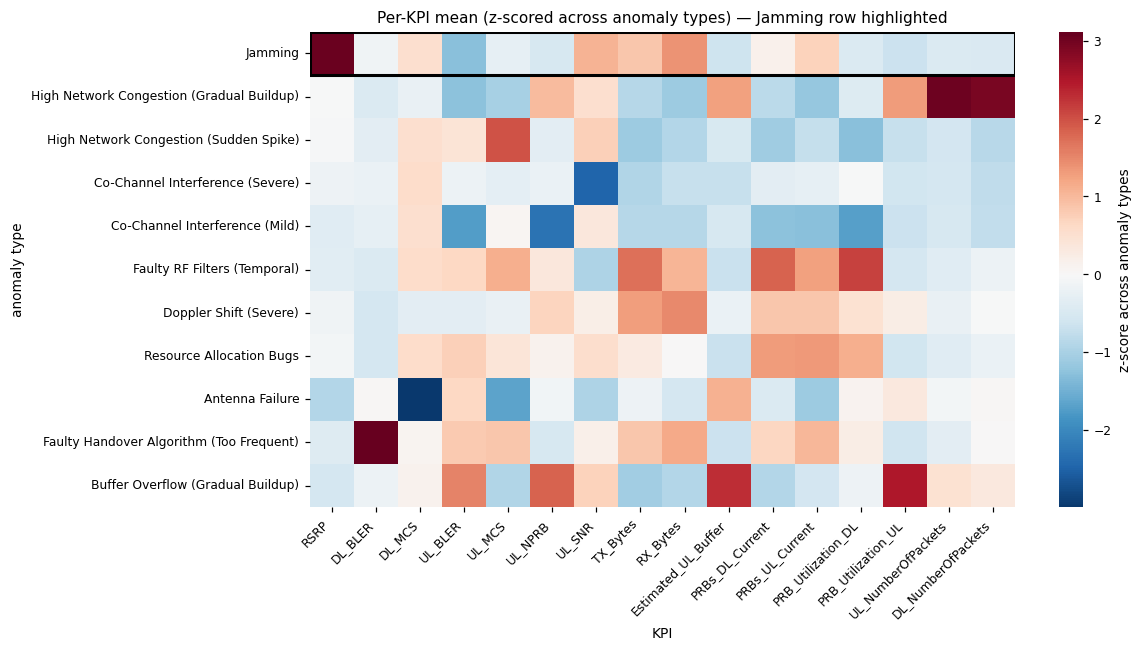

saved experiments/E2_distribution_gap_robustness/figures/E2_kpi_heatmap.pdf


In [21]:
# Figure 1 — z-scored mean of each KPI per anomaly type (11 x 16).
type_kpi_means = []
for t in ANOMALY_TYPES:
    mask_t = corpus.anomaly_type == t
    if mask_t.sum() == 0:
        type_kpi_means.append(np.full(len(KPI_NAMES), np.nan))
    else:
        # mean over windows then over time dimension
        type_kpi_means.append(corpus.X[mask_t].mean(axis=(0, 1)))
type_kpi_means = np.vstack(type_kpi_means)

mu = type_kpi_means.mean(axis=0, keepdims=True)
sd = type_kpi_means.std(axis=0, keepdims=True)
sd_safe = np.where(sd == 0, 1.0, sd)
z_types = (type_kpi_means - mu) / sd_safe

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    z_types,
    cmap='RdBu_r',
    center=0,
    xticklabels=list(KPI_NAMES),
    yticklabels=list(ANOMALY_TYPES),
    ax=ax,
    cbar_kws={'label': 'z-score across anomaly types'},
)
jam_idx = list(ANOMALY_TYPES).index('Jamming')
ax.add_patch(plt.Rectangle((0, jam_idx), len(KPI_NAMES), 1, fill=False, edgecolor='black', lw=2.0))
ax.set_xlabel('KPI')
ax.set_ylabel('anomaly type')
ax.set_title('Per-KPI mean (z-scored across anomaly types) — Jamming row highlighted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig(FIGURES / 'E2_kpi_heatmap.pdf')
plt.show()
print('saved', FIGURES / 'E2_kpi_heatmap.pdf')


anomaly windows for PCA/t-SNE: (1235, 240)


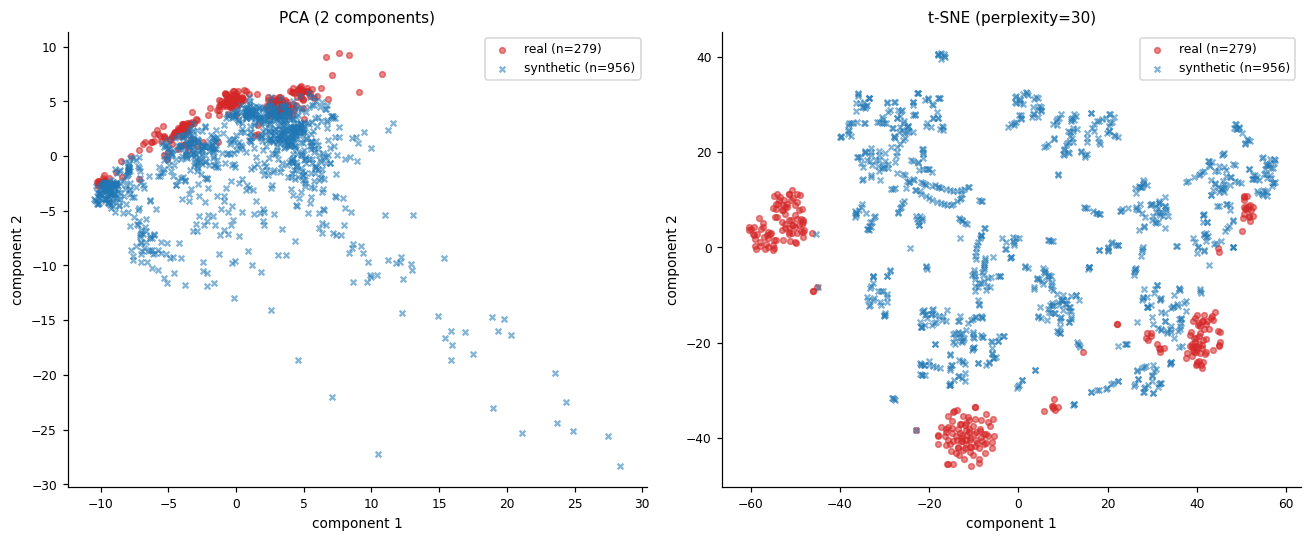

saved experiments/E2_distribution_gap_robustness/figures/E2_feature_space_pca_tsne.pdf


In [22]:
# Figure 2 — PCA + t-SNE of all anomaly windows in standardised engineered-feature space.
anom_mask_global = real_mask | synth_mask
F_anom = F_full[anom_mask_global].astype(np.float64)
origin_anom = corpus.anomaly_origin[anom_mask_global]
scaler_v = StandardScaler()
F_anom_std = scaler_v.fit_transform(F_anom)
print('anomaly windows for PCA/t-SNE:', F_anom_std.shape)

pca = PCA(n_components=2, random_state=0)
F_pca = pca.fit_transform(F_anom_std)
tsne = TSNE(n_components=2, perplexity=30, random_state=0, max_iter=1000, init='random')
F_tsne = tsne.fit_transform(F_anom_std)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, F_emb, title in zip(axes, [F_pca, F_tsne], ['PCA (2 components)', 't-SNE (perplexity=30)']):
    for origin, color, marker in [('real', 'tab:red', 'o'), ('synthetic', 'tab:blue', 'x')]:
        m = origin_anom == origin
        ax.scatter(F_emb[m, 0], F_emb[m, 1], s=14, alpha=0.55, label=f'{origin} (n={int(m.sum())})', c=color, marker=marker)
    ax.set_title(title)
    ax.set_xlabel('component 1')
    ax.set_ylabel('component 2')
    ax.legend(loc='best')
plt.tight_layout()
fig.savefig(FIGURES / 'E2_feature_space_pca_tsne.pdf')
plt.show()
print('saved', FIGURES / 'E2_feature_space_pca_tsne.pdf')


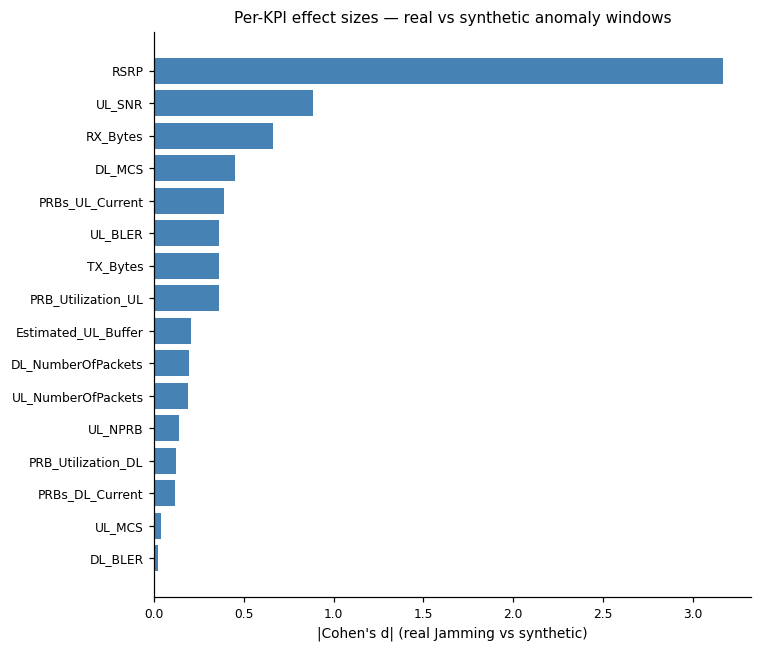

saved experiments/E2_distribution_gap_robustness/figures/E2_top_kpi_effect_sizes.pdf


In [23]:
# Figure 3 — Top KPI |Cohen's d| values (real Jamming vs synthetic).
df_eff = per_kpi_full[['kpi', 'abs_d']].copy().sort_values('abs_d', ascending=True)
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(df_eff['kpi'], df_eff['abs_d'], color='steelblue')
ax.set_xlabel(r"|Cohen's d| (real Jamming vs synthetic)")
ax.set_title('Per-KPI effect sizes — real vs synthetic anomaly windows')
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'E2_top_kpi_effect_sizes.pdf')
plt.show()
print('saved', FIGURES / 'E2_top_kpi_effect_sizes.pdf')


## Wrap-up — what is and is not supported

This notebook provides quantitative evidence about the real-vs-synthetic gap in
TelecomTS. Specifically:

* **Supported by Part A** (`results/E2_per_kpi_real_synthetic_tests.csv`,
  `results/E2_per_kpi_rankings.csv`): per-KPI marginal differences are visible in KS
  statistic, |Cohen's d|, and Wasserstein-z; multiplicity is controlled with both
  Bonferroni and Benjamini–Hochberg. Effect sizes and rankings tell us *which* KPIs
  drive the gap.
* **Supported by Part B** (`results/E2_c2st_results.csv`): joint distinguishability is
  measured by C2ST accuracy / AUROC / macro-F1 / balanced accuracy across three
  classifiers and five feature subsets. Comparing `phy_only`, `rsrp_only`, and
  `exclude_rsrp` indicates whether the gap is concentrated in PHY-layer KPIs or
  is broadly distributed.
* **Supported by Part C** (`results/E2_mmd_results.csv`): an RBF-kernel MMD test with
  a permutation null gives a classifier-agnostic p-value and effect-size ratio.
* **Supported by Part D** (`results/E2_context_distribution_by_origin.csv`,
  `results/E2_context_matched_per_kpi_tests.csv`,
  `results/E2_context_matched_c2st.csv`,
  `results/E2_context_matched_mmd.csv`): we report whether the gap survives matching
  on `(zone, application, mobility, congestion)`. The matching strategy that was used
  ('exact' or 'propensity') is recorded in each output.
* **Supported by Part D'** (`results/E2_zone_a_only_per_kpi_tests.csv`,
  `results/E2_zone_a_only_c2st.csv`, `results/E2_zone_a_only_mmd.csv`): the
  Zone-A-restricted variant isolates the *real-vs-synthetic mechanism* gap from
  the *Zone-A-vs-A/B/C path-loss* confound that exists by collection design
  (real Jamming was only collected in Zone A; see
  `E1_dataset_split_leakage_audit/results/E1_collection_findings.json`).
* **Supported by Part E** (`results/E2_three_way_centroid_distances.csv`): coarse
  geometric summary of how far apart the `normal`, `real`, and `synthetic` centroids
  are in standardised engineered-feature space.

What is **not** supported by this notebook:

* The PCA and t-SNE visualisations in `figures/E2_feature_space_pca_tsne.pdf` are
  illustrative only. They do **not** prove or disprove "complete separation" of the
  two anomaly populations; for separation claims we rely on the C2ST and MMD numbers.
* No anomaly-type names, descriptions, or troubleshooting tickets are used at any
  point. All inference is from numeric KPIs and engineered KPI summary features.
* Context matching is on the four canonical context fields only; any unmeasured
  confounders (time of day, equipment vendor, etc.) are not adjusted for.
* The MMD permutation p-value uses 1000 permutations; floor p-values should be read
  as `<= 1 / 1001` rather than as exact zeros.

Files written by this notebook:

* `results/E2_per_kpi_real_synthetic_tests.csv`
* `results/E2_per_kpi_rankings.csv`
* `results/E2_c2st_results.csv`
* `results/E2_mmd_results.csv`
* `results/E2_context_distribution_by_origin.csv`
* `results/E2_context_matched_per_kpi_tests.csv`
* `results/E2_context_matched_c2st.csv`
* `results/E2_context_matched_mmd.csv`
* `results/E2_zone_a_only_per_kpi_tests.csv`
* `results/E2_zone_a_only_c2st.csv`
* `results/E2_zone_a_only_mmd.csv`
* `results/E2_three_way_centroid_distances.csv`
* `figures/E2_kpi_heatmap.pdf`
* `figures/E2_feature_space_pca_tsne.pdf`
* `figures/E2_top_kpi_effect_sizes.pdf`
